<a href="https://colab.research.google.com/github/Shwe30/Islet-counting/blob/main/cell_counting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================
# INSTALL LIBRARIES (Colab)
# ===============================
!pip install opencv-python-headless scikit-image scikit-learn

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, morphology, measure, segmentation
from scipy import ndimage as ndi
from sklearn.cluster import KMeans
import pandas as pd

Saving TV128 [2].jpg to TV128 [2] (2).jpg
Processing: TV128 [2] (2).jpg
Insulin: 11
Glucagon: 13
Nuclei: 24
Glucagon in core: 1
Glucagon in border: 12
Islet area: 884288
Insulin area: 238532
Glucagon_area: 346405


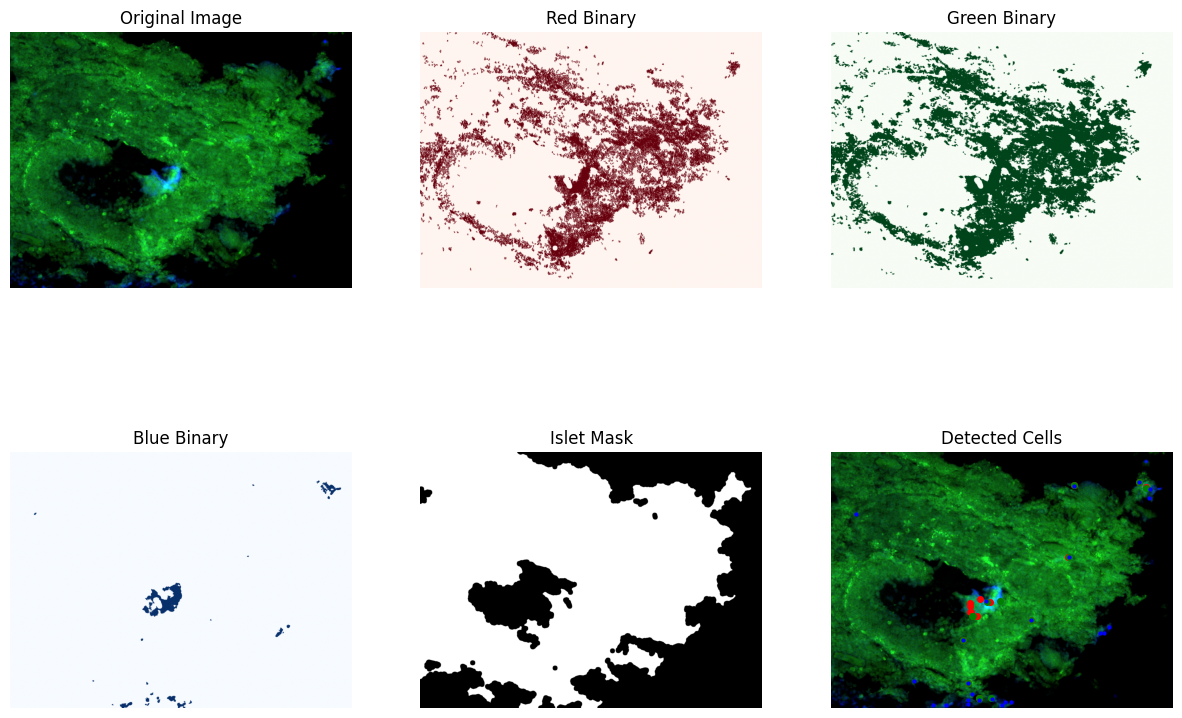

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel file created.


In [ ]:

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects
from skimage import filters, morphology
from google.colab import files

uploaded = files.upload()

results = []


def kmeans_binary(channel, mask):

    pixels = channel[mask].reshape(-1,1)

    kmeans = KMeans(n_clusters=2, random_state=0).fit(pixels)

    labels = np.zeros(channel.shape)

    cluster_labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    signal_cluster = np.argmax(centers)

    labels_masked = (cluster_labels == signal_cluster).astype(np.uint8)

    labels[mask] = labels_masked

    return labels.astype(np.uint8)

for image_name in uploaded.keys():

    print("Processing:", image_name)

    img = cv2.imread(image_name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    red = img[:,:,0]
    green = img[:,:,1]
    blue = img[:,:,2]


    combined = red + green + blue
    combined = cv2.GaussianBlur(combined, (5,5), 0)

    thresh_val = filters.threshold_otsu(combined)
    islet_mask = combined > thresh_val

    islet_mask = morphology.remove_small_objects(islet_mask, 500)
    islet_mask = morphology.closing(islet_mask, morphology.disk(10))


    labels = label(islet_mask)
    regions = regionprops(labels)

    if len(regions) == 0:
        continue

    largest_region = max(regions, key=lambda x: x.area)
    islet_mask = labels == largest_region.label
    islet_area_pixels=np.sum(islet_mask)
    distance_map=ndi.distance_transform_edt(islet_mask)
    max_dist=distance_map.max()
    core_mask=distance_map>(0.5*max_dist)
    border_mask=(distance_map>0)&(distance_map<=(0.5*max_dist))


    red_mask = kmeans_binary(red, islet_mask)
    green_mask = kmeans_binary(green, islet_mask)
    green_core_mask=kmeans_binary(green,core_mask)
    green_border_mask=kmeans_binary(green,border_mask)
    blue_mask = kmeans_binary(blue, islet_mask)

    red_mask = remove_small_objects(red_mask.astype(bool), 20)
    green_mask = remove_small_objects(green_mask.astype(bool), 20)
    green_core_mask = remove_small_objects(green_core_mask.astype(bool), 20)
    green_border_mask = remove_small_objects(green_border_mask.astype(bool), 20)
    blue_mask = remove_small_objects(blue_mask.astype(bool), 20)


    insulin_pixels = np.logical_and(red_mask==1, blue_mask==1)
    insulin_labels = label(insulin_pixels)
    insulin_regions = regionprops(insulin_labels)
    #insulin_count = len(insulin_regions)
    insulin_area_pixels = np.sum(red_mask)
    glucagon_area_pixels = np.sum(green_mask)


    glucagon_pixels = np.logical_and(green_mask==1, blue_mask==1)
    glucagon_labels = label(glucagon_pixels)
    glucagon_regions = regionprops(glucagon_labels)
    glucagon_count = len(glucagon_regions)

    glucagon_core_pixels = np.logical_and(green_core_mask==1, blue_mask==1)
    glucagon_core_labels = label(glucagon_core_pixels)
    glucagon_core_regions = regionprops(glucagon_core_labels)
    #glucagon_core_count = len(glucagon_core_regions)

    glucagon_border_pixels = np.logical_and(green_border_mask==1, blue_mask==1)
    glucagon_border_labels = label(glucagon_border_pixels)
    glucagon_border_regions = regionprops(glucagon_border_labels)
    glucagon_border_count = len(glucagon_border_regions)
    glucagon_core_count = glucagon_count - glucagon_border_count

    nuclei_labels = label(blue_mask)
    nuclei_regions = regionprops(nuclei_labels)
    nuclei_count = len(nuclei_regions)

    insulin_count = nuclei_count-glucagon_count

    print("Insulin:", insulin_count)
    print("Glucagon:", glucagon_count)
    print("Nuclei:", nuclei_count)
    print("Glucagon in core:",glucagon_core_count)
    print("Glucagon in border:",glucagon_border_count)
    print("Islet area:",islet_area_pixels)
    print("Insulin area:",insulin_area_pixels)
    print("Glucagon_area:",glucagon_area_pixels)


    fig, ax = plt.subplots(2,3, figsize=(15,10))

    ax[0,0].imshow(img)
    ax[0,0].set_title("Original Image")

    ax[0,1].imshow(red_mask, cmap="Reds")
    ax[0,1].set_title("Red Binary")

    ax[0,2].imshow(green_mask, cmap="Greens")
    ax[0,2].set_title("Green Binary")

    ax[1,0].imshow(blue_mask, cmap="Blues")
    ax[1,0].set_title("Blue Binary")

    ax[1,1].imshow(islet_mask, cmap="gray")
    ax[1,1].set_title("Islet Mask")

    ax[1,2].imshow(img)


    for r in insulin_regions:
        y,x = r.centroid
        ax[1,2].plot(x,y,'ro', markersize=4)


    for r in glucagon_regions:
        y,x = r.centroid
        ax[1,2].plot(x,y,'go', markersize=4)


    for r in nuclei_regions:
        y,x = r.centroid
        ax[1,2].plot(x,y,'bo', markersize=2)

    ax[1,2].set_title("Detected Cells")

    for a in ax.flatten():
        a.axis("off")

    plt.show()


    results.append({
        "Image": image_name,
        "Insulin Count": insulin_count,
        "Glucagon Count": glucagon_count,
        "Glucagon core count":glucagon_core_count,
        "Glucagon border count":glucagon_border_count,
        "Nucleus Count": nuclei_count,
        "Islet area":islet_area_pixels,
        "Insulin area": insulin_area_pixels,
        "Glucagon area": glucagon_area_pixels
    })



df = pd.DataFrame(results)

excel_name = "cell_counts.xlsx"
df.to_excel(excel_name, index=False)

files.download(excel_name)

print("Excel file created.")

Saving TV6 [2].jpg to TV6 [2] (9).jpg


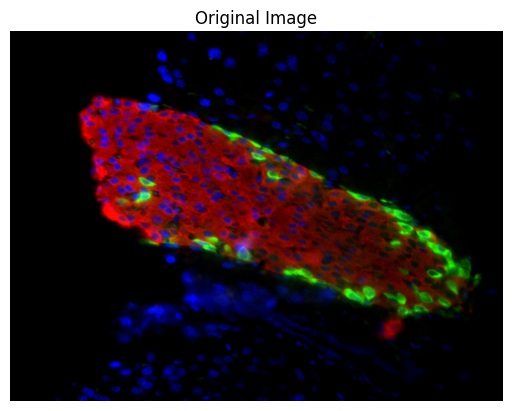

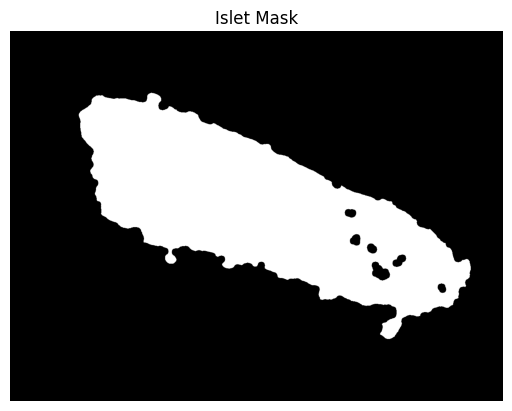

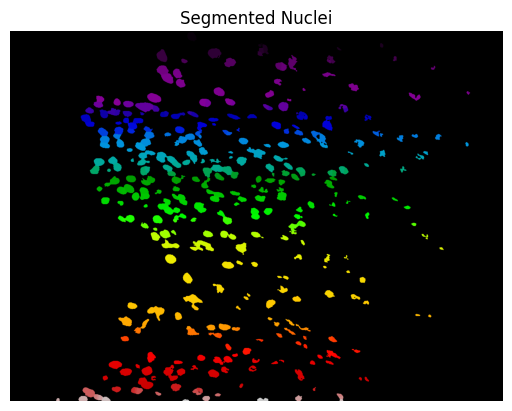

Insulin positive cells: 180
Glucagon positive cells: 14
DAPI nuclei: 37


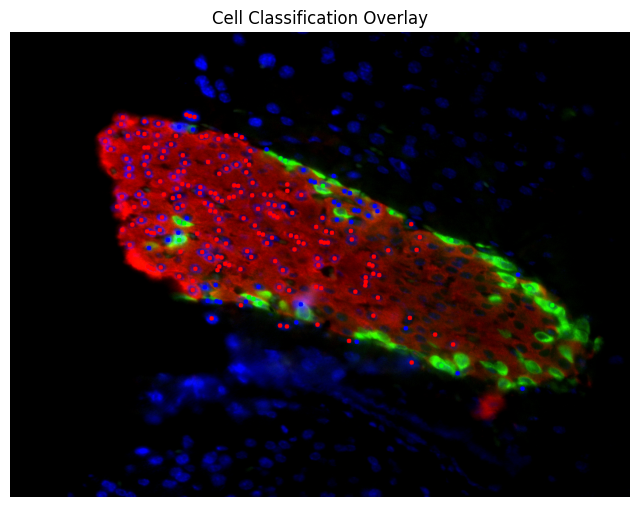

In [ ]:

from google.colab import files
uploaded = files.upload()


image_path = list(uploaded.keys())[0]


img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


red = img[:,:,0]
green = img[:,:,1]
blue = img[:,:,2]

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

combined = red + green + blue
combined = cv2.GaussianBlur(combined, (5,5), 0)

thresh_val = filters.threshold_otsu(combined)
islet_mask = combined > thresh_val


islet_mask = morphology.remove_small_objects(islet_mask, 500)
islet_mask = morphology.closing(islet_mask, morphology.disk(10))

# Keep largest connected component (main islet)
labels = measure.label(islet_mask)
regions = measure.regionprops(labels)

largest_region = max(regions, key=lambda x: x.area)
islet_mask = labels == largest_region.label

plt.imshow(islet_mask, cmap='gray')
plt.title("Islet Mask")
plt.axis("off")
plt.show()

# ===============================
# STEP 2: NUCLEI SEGMENTATION (DAPI)
# ===============================
#background subtraction
from skimage.morphology import white_tophat, disk
red=white_tophat(red, disk(15))
#green=white_tophat(green, disk(15))
blue=white_tophat(blue, disk(15))

#normalisation
red=red/red.max()
#green=green/green.max()
blue=blue/blue.max()

blue_blur = cv2.GaussianBlur(blue, (3,3), 0)
nuc_thresh = filters.threshold_otsu(blue_blur)
nuclei_mask = blue_blur > nuc_thresh

# Remove small debris
nuclei_mask = morphology.remove_small_objects(nuclei_mask, 50)

# Distance transform for watershed
distance = ndi.distance_transform_edt(nuclei_mask)
local_max = morphology.h_maxima(distance, 0.1)
markers = measure.label(local_max)
labels_ws = segmentation.watershed(-distance, markers, mask=nuclei_mask)

plt.imshow(labels_ws, cmap='nipy_spectral')
plt.title("Segmented Nuclei")
plt.axis("off")
plt.show()

# ===============================
# STEP 3: CLASSIFY NUCLEI
# ===============================
if islet_mask.any():
  # Filter labels_ws to include only nuclei within the islet_mask
  labels_ws_in_islet = labels_ws * islet_mask # Zero out nuclei labels outside the islet
  labels_ws_in_islet, _, _ = segmentation.relabel_sequential(labels_ws_in_islet) # Relabel for regionprops

  regions = measure.regionprops(labels_ws_in_islet, intensity_image=red)

  features = []
  valid_regions = []

  for region in regions:
    if region.area > 50:  # filter tiny objects (region.label 0 is background and ignored by regionprops)
      coords = region.coords
      mean_red = np.median(red[coords[:,0], coords[:,1]])
      mean_green = np.mean(green[coords[:,0], coords[:,1]])
      mean_blue=np.median(blue[coords[:,0], coords[:,1]])
      if mean_blue>30:
        continue
      features.append([mean_red, mean_green, mean_blue])
      valid_regions.append(region)

  features = np.array(features)

  kmeans = KMeans(n_clusters=3, random_state=0).fit(features)
  labels_k = kmeans.labels_


  cluster_centers = kmeans.cluster_centers_


  all_clusters = list(range(kmeans.n_clusters))

  insulin_cluster = np.argmax(cluster_centers[:, 0])
  all_clusters.remove(insulin_cluster)


  remaining_cluster_centers_temp = cluster_centers[all_clusters, :]
  glucagon_relative_idx = np.argmax(remaining_cluster_centers_temp[:, 1])
  glucagon_cluster = all_clusters[glucagon_relative_idx]
  all_clusters.remove(glucagon_cluster)


  dapi_cluster = all_clusters[0]


  insulin_count = np.sum(labels_k == insulin_cluster)
  glucagon_count = np.sum(labels_k == glucagon_cluster)
  dapi_count= np.sum(labels_k == dapi_cluster)

#data={"Insulin count":[insulin_count],"Glucagon count":[glucagon_count],"Nucleus count":[dapi_count]}

print("Insulin positive cells:", insulin_count)
print("Glucagon positive cells:", glucagon_count)
print("DAPI nuclei:", dapi_count)



overlay = img.copy()

for i, region in enumerate(valid_regions):
    y, x = region.centroid
    y, x = int(y), int(x)

    if labels_k[i] == insulin_cluster:
        cv2.circle(overlay, (x,y), 5, (255,0,0), -1)
    elif labels_k[i] == glucagon_cluster:
        cv2.circle(overlay, (x,y), 5, (0,255,0), -1)
    elif labels_k[i] == dapi_cluster:
        cv2.circle(overlay, (x,y), 5, (0,0,255), -1)

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.title("Cell Classification Overlay")
plt.axis("off")
plt.show()

In [ ]:

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from skimage import filters, morphology, measure, segmentation
from skimage.morphology import white_tophat, disk
from sklearn.cluster import KMeans
import scipy.ndimage as ndi

uploaded = files.upload()

results = []
for image_path in uploaded.keys():

  print("Processing:", image_path)


  img = cv2.imread(image_path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  red = img[:,:,0]
  green = img[:,:,1]
  blue = img[:,:,2]


  combined = red + green + blue
  combined = cv2.GaussianBlur(combined, (5,5), 0)

  thresh_val = filters.threshold_otsu(combined)
  islet_mask = combined > thresh_val

  islet_mask = morphology.remove_small_objects(islet_mask, 500)
  islet_mask = morphology.closing(islet_mask, morphology.disk(10))

  labels = measure.label(islet_mask)
  regions = measure.regionprops(labels)

  if len(regions) == 0:
      continue

  largest_region = max(regions, key=lambda x: x.area)
  islet_mask = labels == largest_region.label


  blue = white_tophat(blue, disk(15))

  red = cv2.GaussianBlur(red,(5,5),0)

  red = red/red.max()
  blue = blue/blue.max()

  blue_blur = cv2.GaussianBlur(blue, (3,3), 0)
  nuc_thresh = filters.threshold_otsu(blue_blur)
  nuclei_mask = blue_blur > nuc_thresh

  nuclei_mask = morphology.remove_small_objects(nuclei_mask, 50)

  distance = ndi.distance_transform_edt(nuclei_mask)
  local_max = morphology.h_maxima(distance, 0.1)
  markers = measure.label(local_max)

  labels_ws = segmentation.watershed(-distance, markers, mask=nuclei_mask)



  labels_ws_in_islet = labels_ws * islet_mask
  labels_ws_in_islet, _, _ = segmentation.relabel_sequential(labels_ws_in_islet)

  regions = measure.regionprops(labels_ws_in_islet, intensity_image=red)

  features = []
  valid_regions = []

  for region in regions:

      if region.area > 50:

          coords = region.coords

          mean_red = np.median(red[coords[:,0], coords[:,1]])
          mean_green = np.mean(green[coords[:,0], coords[:,1]])
          mean_blue = np.median(blue[coords[:,0], coords[:,1]])

          if mean_blue > 30 and mean_red < 20 and mean_green < 20:
              continue

          features.append([mean_red, mean_green, mean_blue])
          valid_regions.append(region)

  if len(features) < 3:
      continue

  features = np.array(features)


  kmeans = KMeans(n_clusters=3, random_state=0).fit(features)
  labels_k = kmeans.labels_

  cluster_centers = kmeans.cluster_centers_

  all_clusters = list(range(3))

  insulin_cluster = np.argmax(cluster_centers[:,0])
  all_clusters.remove(insulin_cluster)

  remaining = cluster_centers[all_clusters,:]
  glucagon_relative_idx = np.argmax(remaining[:,1])
  glucagon_cluster = all_clusters[glucagon_relative_idx]

  all_clusters.remove(glucagon_cluster)
  dapi_cluster = all_clusters[0]

  insulin_count = np.sum(labels_k == insulin_cluster)
  glucagon_count = np.sum(labels_k == glucagon_cluster)
  dapi_count = np.sum(labels_k == dapi_cluster)

  print("Insulin:", insulin_count)
  print("Glucagon:", glucagon_count)
  print("Nucleus:", dapi_count)


  results.append({
      "Image Name": image_path,
      "Insulin Count": insulin_count,
      "Glucagon Count": glucagon_count,
      "Nucleus Count": dapi_count
  })


df = pd.DataFrame(results)

excel_name = "islet_cell_counts.xlsx"
df.to_excel(excel_name, index=False)

files.download(excel_name)

print("Excel file generated.")

Saving TV128 [2].jpg to TV128 [2] (1).jpg
Processing: TV128 [2] (1).jpg
Insulin: 339
Glucagon: 963
Nucleus: 765


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel file generated.


Saving TV128 [2].jpg to TV128 [2] (3).jpg
Processing: TV128 [2] (3).jpg
KI67: 12
Cells: 25


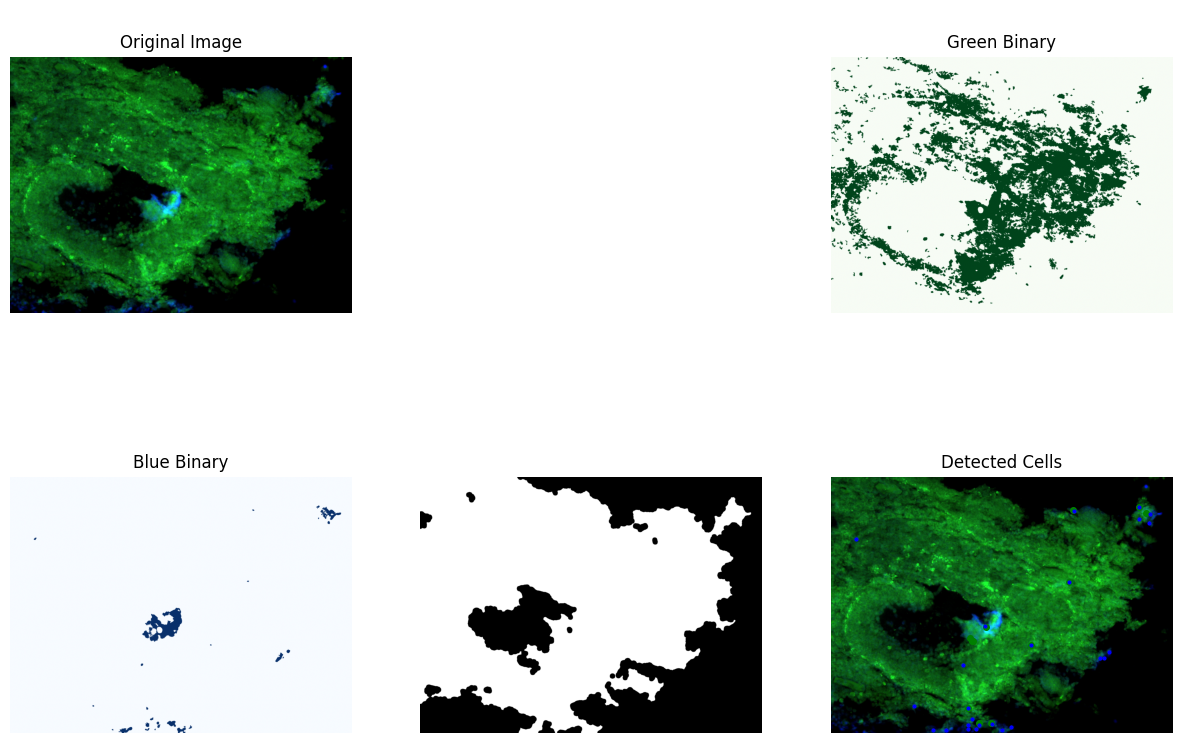

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel file created.


In [ ]:
# ova KI 67 cells counting
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects
from skimage import filters, morphology
from google.colab import files

uploaded = files.upload()

results = []


def kmeans_binary(channel, mask):

    pixels = channel[mask].reshape(-1,1)

    kmeans = KMeans(n_clusters=2, random_state=0).fit(pixels)

    labels = np.zeros(channel.shape)

    cluster_labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    signal_cluster = np.argmax(centers)

    labels_masked = (cluster_labels == signal_cluster).astype(np.uint8)

    labels[mask] = labels_masked

    return labels.astype(np.uint8)

for image_name in uploaded.keys():

    print("Processing:", image_name)

    img = cv2.imread(image_name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    green = img[:,:,1]
    blue = img[:,:,2]


    combined =  green + blue
    combined = cv2.GaussianBlur(combined, (5,5), 0)

    thresh_val = filters.threshold_otsu(combined)
    islet_mask = combined > thresh_val

    islet_mask = morphology.remove_small_objects(islet_mask, 500)
    islet_mask = morphology.closing(islet_mask, morphology.disk(10))


    labels = label(islet_mask)
    regions = regionprops(labels)

    if len(regions) == 0:
        continue

    largest_region = max(regions, key=lambda x: x.area)
    islet_mask = labels == largest_region.label
    islet_area_pixels=np.sum(islet_mask)
    distance_map=ndi.distance_transform_edt(islet_mask)
    max_dist=distance_map.max()
    core_mask=distance_map>(0.5*max_dist)
    border_mask=(distance_map>0)&(distance_map<=(0.5*max_dist))



    green_mask = kmeans_binary(green, islet_mask)


    blue_mask = kmeans_binary(blue, islet_mask)


    green_mask = remove_small_objects(green_mask.astype(bool), 20)

    blue_mask = remove_small_objects(blue_mask.astype(bool), 20)



    KI67_area_pixels = np.sum(green_mask)


    KI67_pixels = np.logical_and(green_mask==1, blue_mask==1)
    KI67_labels = label(KI67_pixels)
    KI67_regions = regionprops(KI67_labels)
    KI67_count = len(KI67_regions)



    cells_labels = label(blue_mask)
    cells_regions = regionprops(cells_labels)
    cells_count = len(cells_regions)




    print("KI67:", KI67_count)
    print("Cells:", cells_count)



    fig, ax = plt.subplots(2,3, figsize=(15,10))

    ax[0,0].imshow(img)
    ax[0,0].set_title("Original Image")



    ax[0,2].imshow(green_mask, cmap="Greens")
    ax[0,2].set_title("Green Binary")

    ax[1,0].imshow(blue_mask, cmap="Blues")
    ax[1,0].set_title("Blue Binary")

    ax[1,1].imshow(islet_mask, cmap="gray")


    ax[1,2].imshow(img)




    for r in KI67_regions:
        y,x = r.centroid
        ax[1,2].plot(x,y,'go', markersize=4)


    for r in cells_regions:
        y,x = r.centroid
        ax[1,2].plot(x,y,'bo', markersize=2)

    ax[1,2].set_title("Detected Cells")

    for a in ax.flatten():
        a.axis("off")

    plt.show()


    results.append({
        "Image": image_name,
        "KI67 Count": KI67_count,
        "Cells Count": cells_count,
        "KI67 %":KI67_count/cells_count*100

    })



df = pd.DataFrame(results)

excel_name = "cell_counts.xlsx"
df.to_excel(excel_name, index=False)

files.download(excel_name)

print("Excel file created.")